In [ ]:
# ##############################################################
# MobileSAM LoRA Finetuning for Prompt Robustness on ACDC
#
# Pipeline:
#   1  Install + imports
#   2  Config (single source of truth for all constants)
#   3  Shared helpers (dice, box jitter, viz utils)
#   4  Load MobileSAM + build predictor
#   5  Load ACDC data (multi-class, multiple patients)
#   6  Sanity viz: structures + boxes
#   7  Per-structure robustness — BEFORE (stock MobileSAM)
#   8  Per-structure BEFORE charts
#   9  LoRA wiring (decoder + prompt encoder)
#   10 Training dataset (jittered-box augmentation)
#   11 Train loop + loss curve
#   12 Per-structure robustness — AFTER (LoRA model)
#   13 Before/after charts (overall + per structure)
#   14 Before/after visual panels
#   15 Final summary table + save
# ##############################################################

In [1]:
# ==============================================================
# CELL 1 — Install + imports
# ==============================================================
!pip -q install git+https://github.com/ChaoningZhang/MobileSAM.git
!pip -q install peft loralib nibabel scipy matplotlib

import os, math, random, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

  Preparing metadata (setup.py) ... done
torch: 2.11.0+cu128 cuda: True


In [26]:
# ==============================================================
# CELL 2 — Config (single source of truth)
# Every other cell reads from here. Never redefine these elsewhere.
# ==============================================================
class CFG:
    # Reproducibility
    SEED         = 42

    # Noise sweep (bounding-box jitter in pixels)
    SIGMA_VALUES = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
    TRAIN_SIGMA  = 0.20
    N_TRIALS=30             # eval trials per sigma (median + IQR)

    # ACDC label convention (verified in CELL 5; warns if different)
    #   background=0, RV=1, myocardium=2, LV=3
    LABELS = {"RV": 1, "MYO": 2, "LV": 3}

    # Consistent per-structure colors across ALL figures
    COLORS = {"RV": "#1f77b4", "MYO": "#2ca02c", "LV": "#d62728"}

    # Clinical/quality reference line
    DICE_THRESHOLD = 0.80

    # LoRA
    LORA_R         = 8
    LORA_ALPHA     = 16
    LORA_DROPOUT   = 0.05
    TRAIN_TARGETS  = ("mask_decoder", "prompt_encoder")  # freeze image encoder

    # Training
    EPOCHS         = 20
    BATCH_SIZE     = 4
    LR             = 1e-4
    TRAIN_SIGMA    = 25        # std of box jitter used as AUGMENTATION in training
    VAL_FRACTION   = 0.2

    # Paths (edit to your environment)
    MOBILESAM_CKPT = "/content/mobile_sam.pt"
    ACDC_ROOT      = "/content/ACDC"     # dir of patient folders or preprocessed slices
    OUT_DIR        = "/content/outputs"

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_all_seeds(seed=CFG.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_all_seeds()
print("Config loaded. Structures:", list(CFG.LABELS), "| sigmas:", CFG.SIGMA_VALUES)

Config loaded. Structures: ['RV', 'MYO', 'LV'] | sigmas: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]


In [24]:
# ==============================================================
# CELL 3 — Shared helpers (defined ONCE, used everywhere)
# ==============================================================
def dice_score(pred, gt, eps=1e-6):
    """Dice between two binary masks of identical H,W."""
    pred = np.asarray(pred).astype(bool)
    gt   = np.asarray(gt).astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    if denom == 0:
        return 1.0          # both empty -> perfect agreement
    return float((2.0 * inter + eps) / (denom + eps))


def dice_torch(pred_logits, gt_mask, eps=1e-6):
    """Differentiable soft Dice loss for training (pred_logits: B,1,H,W)."""
    pred = torch.sigmoid(pred_logits)
    gt   = gt_mask.float()
    inter = (pred * gt).sum(dim=(1, 2, 3))
    denom = pred.sum(dim=(1, 2, 3)) + gt.sum(dim=(1, 2, 3))
    dice  = (2 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()


def box_from_mask(mask, pad=0):
    """Tight box [x0,y0,x1,y1] around a binary mask."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return np.array([x0 - pad, y0 - pad, x1 + pad, y1 + pad], dtype=int)


def make_noisy_box(clean_box, sigma, seed, W, H):
    """Deterministic jittered box. Identical output for any caller with
    the same (sigma, seed) — guarantees paired comparisons everywhere."""
    rng = np.random.default_rng(seed)
    if sigma == 0:
        b = clean_box.copy().astype(int)
    else:
        b = clean_box + rng.normal(0, sigma, 4).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1)); b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1)); b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = min(b[0] + 10, W - 1)
    if b[1] >= b[3]: b[3] = min(b[1] + 10, H - 1)
    return b


def median_trial_index(dice_list):
    arr = np.array(dice_list)
    return int(np.argmin(np.abs(arr - np.median(arr))))


def med_iqr(dice_lists_by_sigma, sigmas=CFG.SIGMA_VALUES):
    med = [np.median(dice_lists_by_sigma[s]) for s in sigmas]
    q1  = [np.percentile(dice_lists_by_sigma[s], 25) for s in sigmas]
    q3  = [np.percentile(dice_lists_by_sigma[s], 75) for s in sigmas]
    return np.array(med), np.clip(q1, 0, 1), np.clip(q3, 0, 1)


def to_rgb(gray):
    """ACDC slices are single-channel; SAM expects HxWx3 uint8."""
    g = gray.astype(np.float32)
    g = (g - g.min()) / (np.ptp(g) + 1e-8)   # was g.ptp() — removed in NumPy 2.0
    g = (g * 255).astype(np.uint8)
    return np.stack([g, g, g], axis=-1)

def make_noisy_box_prop(clean_box, frac, seed, W, H):
    """Jitter scaled to box size. Each coordinate is perturbed by
    Normal(0, frac * box_dimension), so frac=0.10 ≈ 10% of the box.
    Deterministic in (frac, seed) -> identical boxes for paired runs."""
    rng = np.random.default_rng(seed)
    bw = max(int(clean_box[2] - clean_box[0]), 1)
    bh = max(int(clean_box[3] - clean_box[1]), 1)
    if frac == 0:
        b = clean_box.copy().astype(int)
    else:
        noise = rng.normal(0, 1, 4) * np.array([bw, bh, bw, bh]) * frac
        b = (clean_box + noise).astype(int)
    b[0] = int(np.clip(b[0], 0, W - 1)); b[1] = int(np.clip(b[1], 0, H - 1))
    b[2] = int(np.clip(b[2], 0, W - 1)); b[3] = int(np.clip(b[3], 0, H - 1))
    if b[0] >= b[2]: b[2] = min(b[0] + 10, W - 1)
    if b[1] >= b[3]: b[3] = min(b[1] + 10, H - 1)
    return b


# Axis-label helper so every chart reads consistently
JITTER_XLABEL = "Box jitter (fraction of box size)"

print("Helpers ready.")

Helpers ready.


In [5]:
import mobile_sam, os, glob, shutil

# The weights file is included in the installed package
pkg_dir = os.path.dirname(mobile_sam.__file__)
hits = glob.glob(os.path.join(pkg_dir, "**", "*.pt"), recursive=True)
print("Found .pt files in package:", hits)

if hits:
    shutil.copy(hits[0], CFG.MOBILESAM_CKPT)
    print(f"Copied {hits[0]} -> {CFG.MOBILESAM_CKPT}")
else:
    print("No .pt in package — download from the repo's weights folder instead.")

Found .pt files in package: []
No .pt in package — download from the repo's weights folder instead.


In [6]:
# Fallback: pull the official checkpoint from the MobileSAM repo
!wget -q https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt \
    -O /content/mobile_sam.pt
!ls -lh /content/mobile_sam.pt

-rw-r--r-- 1 root root 39M Jun  9 22:43 /content/mobile_sam.pt


In [7]:
# ==============================================================
# CELL 4 — Load MobileSAM + predictor
# ==============================================================
from mobile_sam import sam_model_registry, SamPredictor

sam = sam_model_registry["vit_t"](checkpoint=CFG.MOBILESAM_CKPT)
sam.to(DEVICE).eval()
predictor = SamPredictor(sam)

n_params = sum(p.numel() for p in sam.parameters())
print(f"MobileSAM loaded: {n_params/1e6:.2f}M params on {DEVICE}")

# Keep an untouched copy of the original weights for the BEFORE experiment,
# so finetuning later cannot retroactively change the baseline.
import copy as _copy
sam_state_backup = _copy.deepcopy(sam.state_dict())
print("Baseline weights backed up.")

MobileSAM loaded: 10.13M params on cuda
Baseline weights backed up.


In [15]:
import glob, os

# Mount Drive if your data lives there (safe to run even if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Drive not mounted:", e)

print("\n--- Searching for data ---")
patterns = {
    "patient folders": "/content/**/patient[0-9]*",
    "NIfTI files":     "/content/**/*.nii*",
    "npy arrays":      "/content/**/*.npy",
    "npz arrays":      "/content/**/*.npz",
}
found = {}
for label, pat in patterns.items():
    hits = glob.glob(pat, recursive=True)
    found[label] = hits
    print(f"{label}: {len(hits)}")
    for h in hits[:5]:
        print("   ", h)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Searching for data ---
patient folders: 1653
    /content/drive/MyDrive/patient100
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient099
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient097
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient098
NIfTI files: 1352
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091/patient091_4d.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091/patient091_frame01_gt.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091/patient091_frame09_gt.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091/patient091_frame09.nii.gz
    /content/drive/MyDrive/ACDC/ACDC/database/training/patient091/patient091_frame01.nii.gz
npy arrays: 0
npz arrays: 0


In [16]:
# ==============================================================
# CELL 5 — Load ACDC data (multi-class, multiple patients)
# Data lives in Google Drive (standard ACDC NIfTI layout).
# ==============================================================
import glob
import nibabel as nib

# ---- CORRECT PATH (was /content/ACDC, which doesn't exist) ----
CFG.ACDC_ROOT = "/content/drive/MyDrive/ACDC/ACDC/database/training"
assert os.path.isdir(CFG.ACDC_ROOT), f"ACDC_ROOT not found: {CFG.ACDC_ROOT}"


def load_acdc_slices(root, max_patients=None):
    """Standard ACDC: patientXXX/patientXXX_frameYY(.nii.gz / _gt.nii.gz).
    Returns list of dicts {img, mask, patient, z}. Skips empty slices."""
    slices = []
    patient_dirs = sorted(glob.glob(os.path.join(root, "patient*")))
    if max_patients:
        patient_dirs = patient_dirs[:max_patients]

    for pdir in patient_dirs:
        pid = os.path.basename(pdir)
        gt_files = sorted(glob.glob(os.path.join(pdir, f"{pid}_frame*_gt.nii.gz")))
        for gtf in gt_files:
            imgf = gtf.replace("_gt.nii.gz", ".nii.gz")
            if not os.path.exists(imgf):
                continue
            vol = nib.load(imgf).get_fdata()          # H, W, Z
            seg = nib.load(gtf).get_fdata().astype(int)
            if vol.shape != seg.shape:
                print(f"  ⚠ shape mismatch {pid}: img {vol.shape} vs gt {seg.shape}; skipped")
                continue
            for z in range(vol.shape[2]):
                m = seg[:, :, z]
                if (m > 0).sum() < 30:                 # skip slices w/o structures
                    continue
                slices.append({"img": vol[:, :, z], "mask": m,
                               "patient": pid, "z": z,
                               "frame": os.path.basename(gtf)})
    return slices


slices = load_acdc_slices(CFG.ACDC_ROOT, max_patients=None)
assert len(slices) > 0, (
    "Loaded 0 slices. Check that gt files match the *_frame*_gt.nii.gz pattern.")
print(f"Loaded {len(slices)} usable slices "
      f"from {len(set(s['patient'] for s in slices))} patients.")

# ---- Verify label convention ----
present = set()
for s in slices[:300]:
    present.update(np.unique(s["mask"]).tolist())
present.discard(0)
print("Label values present:", sorted(present))
expected = set(CFG.LABELS.values())
if not expected.issubset(present):
    print("⚠ expected", expected, "found", present, "-> edit CFG.LABELS")
else:
    print("✓ Label convention matches CFG.LABELS:", CFG.LABELS)

# ---- Per-structure availability (how many slices contain each) ----
for st, lab in CFG.LABELS.items():
    n = sum(1 for s in slices if (s["mask"] == lab).sum() >= 10)
    print(f"   {st:<4} present in {n}/{len(slices)} slices")

# ---- Patient-level train/val split (no slice leakage) ----
set_all_seeds()
all_patients = sorted(set(s["patient"] for s in slices))
random.shuffle(all_patients)
n_val = max(1, int(len(all_patients) * CFG.VAL_FRACTION))
val_patients   = set(all_patients[:n_val])
train_patients = set(all_patients[n_val:])
train_slices = [s for s in slices if s["patient"] in train_patients]
val_slices   = [s for s in slices if s["patient"] in val_patients]
print(f"\nTrain: {len(train_slices)} slices / {len(train_patients)} patients | "
      f"Val: {len(val_slices)} slices / {len(val_patients)} patients")

Loaded 1807 usable slices from 98 patients.
Label values present: [1, 2, 3]
✓ Label convention matches CFG.LABELS: {'RV': 1, 'MYO': 2, 'LV': 3}
   RV   present in 1526/1807 slices
   MYO  present in 1796/1807 slices
   LV   present in 1774/1807 slices

Train: 1459 slices / 79 patients | Val: 348 slices / 19 patients


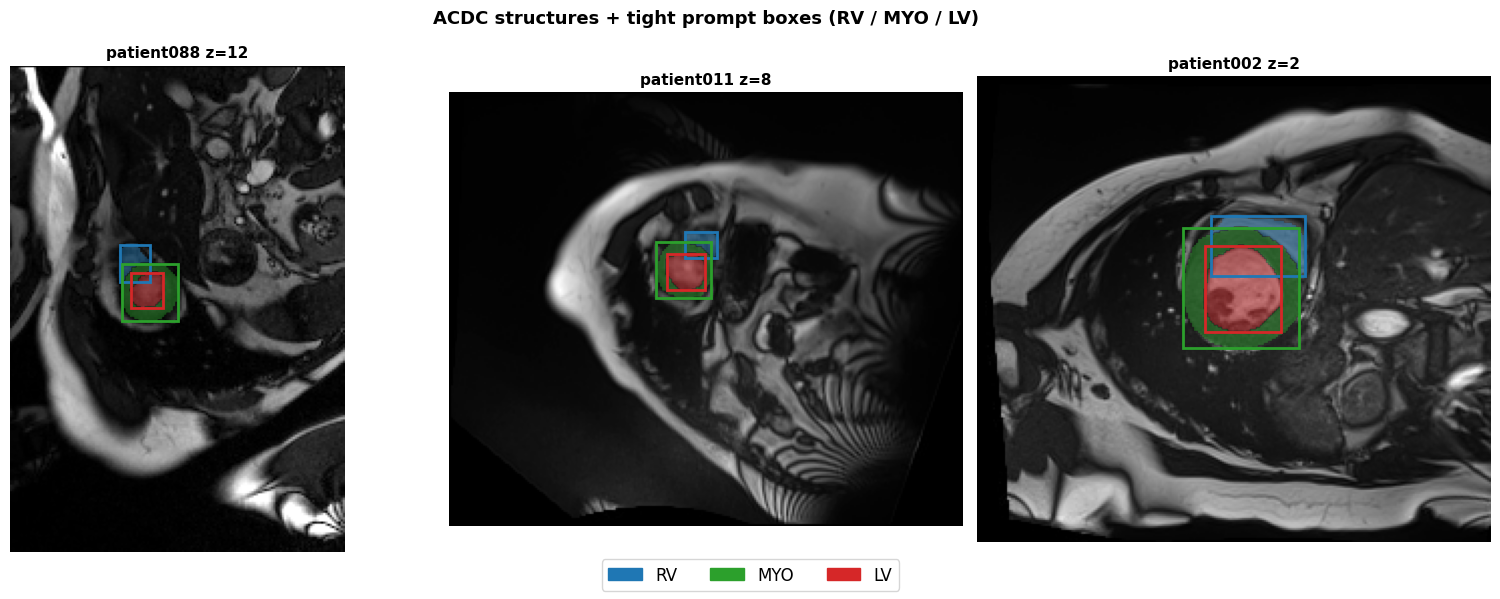

Saved: sanity_structures.png


In [20]:
# ==============================================================
# CELL 6 — Sanity viz: structures + their boxes on a few slices
# Confirms labels/colors/boxes are correct BEFORE any experiment.
# ==============================================================
def structure_mask(full_mask, struct):
    return (full_mask == CFG.LABELS[struct]).astype(np.uint8)

set_all_seeds()
viz_slices = random.sample(val_slices, min(3, len(val_slices)))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, s in zip(np.atleast_1d(axes), viz_slices):
    rgb = to_rgb(s["img"])
    H, W = rgb.shape[:2]
    ax.imshow(rgb)
    for struct in CFG.LABELS:
        m = structure_mask(s["mask"], struct)
        if m.sum() == 0:
            continue
        ax.imshow(np.ma.masked_where(m == 0, m), alpha=0.45,
                  cmap=plt.matplotlib.colors.ListedColormap([CFG.COLORS[struct]]))
        box = box_from_mask(m)
        if box is not None:
            ax.add_patch(patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=2, edgecolor=CFG.COLORS[struct], facecolor='none'))
    ax.set_title(f"{s['patient']} z={s['z']}", fontsize=11, fontweight='bold')
    ax.axis('off')

# Legend
handles = [patches.Patch(color=CFG.COLORS[k], label=k) for k in CFG.LABELS]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=12)
plt.suptitle("ACDC structures + tight prompt boxes (RV / MYO / LV)",
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{CFG.OUT_DIR}/sanity_structures.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sanity_structures.png")

In [27]:
# ==============================================================
# CELL 7 — Per-structure robustness experiment (reusable)
# Runs MobileSAM (whatever weights are loaded) on RV/MYO/LV
# separately, across the sigma sweep, on the VAL set.
# Returns nested dict: results[struct][sigma] = [dice per (slice,trial)]
# ==============================================================
def run_per_structure_robustness(predictor, eval_slices, tag, max_slices=None):
    if max_slices:
        eval_slices = eval_slices[:max_slices]

    results   = {st: {s: [] for s in CFG.SIGMA_VALUES} for st in CFG.LABELS}
    repr_store = {st: {s: None for s in CFG.SIGMA_VALUES} for st in CFG.LABELS}

    print(f"\n[{tag}] per-structure robustness over {len(eval_slices)} slices...")
    for si, s in enumerate(eval_slices):
        rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
        predictor.set_image(rgb)
        for struct in CFG.LABELS:
            gt = (s["mask"] == CFG.LABELS[struct]).astype(np.uint8)
            if gt.sum() < 10:
                continue
            clean_box = box_from_mask(gt)
            if clean_box is None:
                continue
            for frac in CFG.SIGMA_VALUES:
                for t in range(CFG.N_TRIALS):
                    # seed uses an index for frac so it's deterministic for floats
                    fi = CFG.SIGMA_VALUES.index(frac)
                    box = make_noisy_box_prop(
                        clean_box, frac,
                        seed=10_000*si + 1000*fi + t, W=W, H=H)
                    with torch.inference_mode():
                        m, _, _ = predictor.predict(
                            point_coords=None, point_labels=None,
                            box=box[None, :], multimask_output=False)
                    d = dice_score(m[0], gt)
                    results[struct][frac].append(d)
                    if repr_store[struct][frac] is None and t == CFG.N_TRIALS//2:
                        repr_store[struct][frac] = {
                            "rgb": rgb, "mask": m[0], "box": box,
                            "gt": gt, "dice": d}
        if (si+1) % 10 == 0:
            print(f"  {si+1}/{len(eval_slices)} slices done")
    return results, repr_store


def summarize(results, tag):
    print(f"\n[{tag}] median Dice vs GT (per structure)")
    header = "frac".ljust(8) + "".join(st.ljust(12) for st in CFG.LABELS)
    print(header); print("-"*len(header))
    for frac in CFG.SIGMA_VALUES:
        row = f"{frac:<8.2f}"
        for st in CFG.LABELS:
            row += f"{np.median(results[st][frac]):<12.4f}"
        print(row)


# ---- BEFORE run (recommended: cap slices so it finishes quickly) ----
sam.load_state_dict(sam_state_backup); sam.eval()
before_results, before_repr = run_per_structure_robustness(
    predictor, val_slices, tag="BEFORE (stock MobileSAM)", max_slices=40)
summarize(before_results, "BEFORE")


[BEFORE (stock MobileSAM)] per-structure robustness over 40 slices...
  10/40 slices done
  20/40 slices done
  30/40 slices done
  40/40 slices done

[BEFORE] median Dice vs GT (per structure)
frac    RV          MYO         LV          
--------------------------------------------
0.00    0.8527      0.4487      0.9263      
0.05    0.8519      0.4284      0.9283      
0.10    0.8360      0.3728      0.9139      
0.15    0.7796      0.3462      0.8728      
0.20    0.6861      0.3104      0.8142      
0.30    0.4549      0.2475      0.6712      


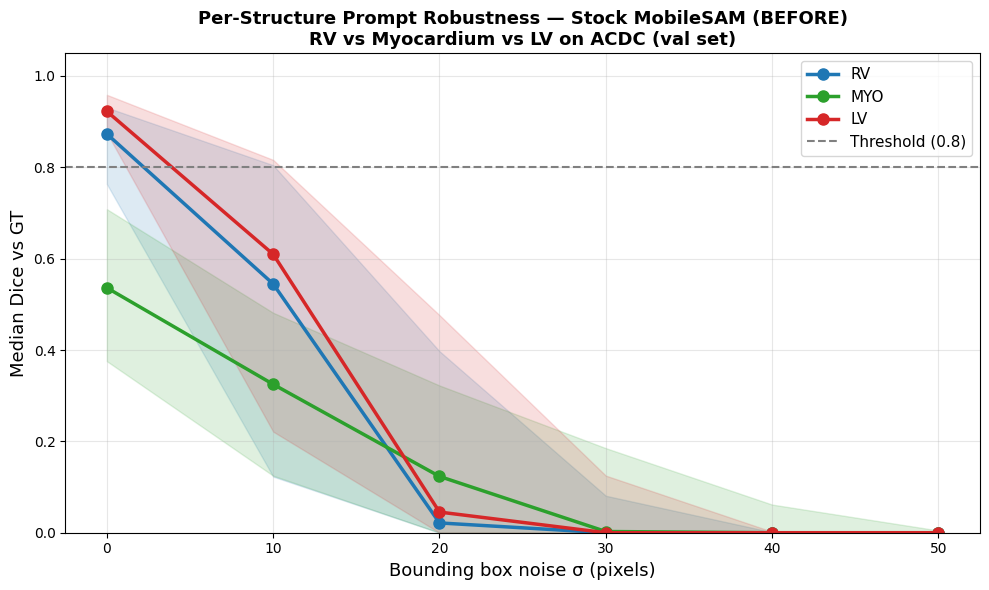

Saved: before_per_structure.png

Degradation σ=0 → σ=30 (larger = less robust):
  RV   0.873 → 0.000   drop = +0.873
  MYO  0.536 → 0.003   drop = +0.534
  LV   0.923 → 0.000   drop = +0.923


In [22]:
# ==============================================================
# CELL 8 — Per-structure BEFORE charts
# One curve per structure (consistent colors) + IQR bands.
# Shows different degradation rates for RV vs MYO vs LV.
# ==============================================================
def plot_per_structure(results, title, savename):
    fig, ax = plt.subplots(figsize=(10, 6))
    for struct in CFG.LABELS:
        med, lo, hi = med_iqr(results[struct])
        ax.plot(CFG.SIGMA_VALUES, med, '-o', color=CFG.COLORS[struct],
                linewidth=2.5, markersize=8, label=struct)
        ax.fill_between(CFG.SIGMA_VALUES, lo, hi, alpha=0.15,
                        color=CFG.COLORS[struct])
    ax.axhline(CFG.DICE_THRESHOLD, color='gray', linestyle='--', linewidth=1.5,
               label=f'Threshold ({CFG.DICE_THRESHOLD})')
    ax.set_xlabel("Bounding box noise σ (pixels)", fontsize=13)
    ax.set_ylabel("Median Dice vs GT", fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.set_xticks(CFG.SIGMA_VALUES)
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT_DIR}/{savename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savename}")

plot_per_structure(
    before_results,
    "Per-Structure Prompt Robustness — Stock MobileSAM (BEFORE)\n"
    "RV vs Myocardium vs LV on ACDC (val set)",
    "before_per_structure.png")

# Which structure degrades fastest? (drop in median Dice from σ=0 to σ=30)
print("\nDegradation σ=0 → σ=30 (larger = less robust):")
for st in CFG.LABELS:
    d0  = np.median(before_results[st][0])
    d30 = np.median(before_results[st][30])
    print(f"  {st:<4} {d0:.3f} → {d30:.3f}   drop = {d0-d30:+.3f}")

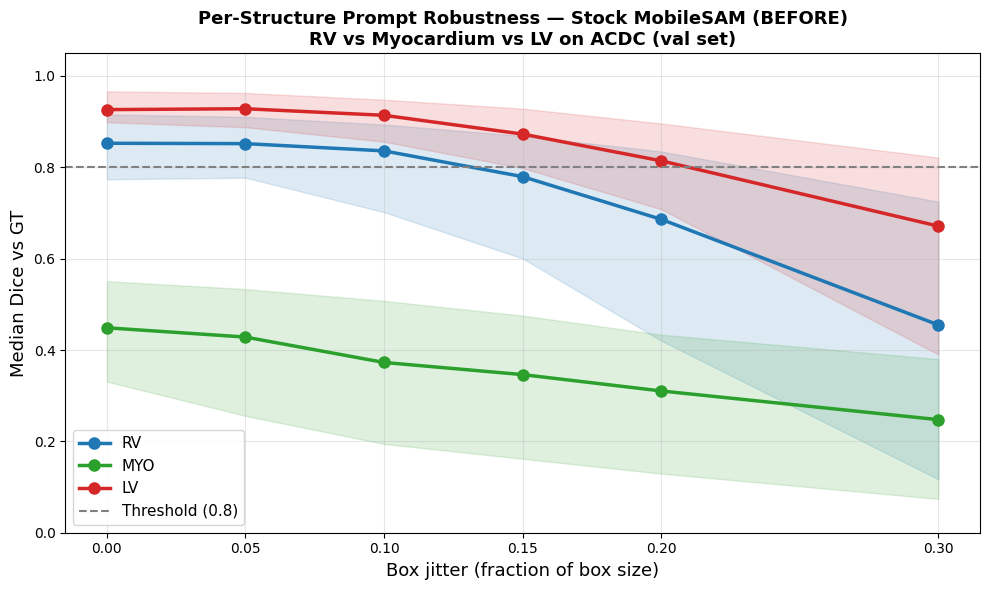

Saved: before_per_structure.png

Degradation from clean to 15% jitter (larger drop = less robust):
  RV   0.853 → 0.780   drop = +0.073
  MYO  0.449 → 0.346   drop = +0.103
  LV   0.926 → 0.873   drop = +0.054


In [28]:
def plot_per_structure(results, title, savename):
    fig, ax = plt.subplots(figsize=(10, 6))
    for struct in CFG.LABELS:
        med, lo, hi = med_iqr(results[struct])
        ax.plot(CFG.SIGMA_VALUES, med, '-o', color=CFG.COLORS[struct],
                linewidth=2.5, markersize=8, label=struct)
        ax.fill_between(CFG.SIGMA_VALUES, lo, hi, alpha=0.15,
                        color=CFG.COLORS[struct])
    ax.axhline(CFG.DICE_THRESHOLD, color='gray', linestyle='--', linewidth=1.5,
               label=f'Threshold ({CFG.DICE_THRESHOLD})')
    ax.set_xlabel(JITTER_XLABEL, fontsize=13)
    ax.set_ylabel("Median Dice vs GT", fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.set_xticks(CFG.SIGMA_VALUES)
    plt.tight_layout()
    plt.savefig(f"{CFG.OUT_DIR}/{savename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savename}")

plot_per_structure(
    before_results,
    "Per-Structure Prompt Robustness — Stock MobileSAM (BEFORE)\n"
    "RV vs Myocardium vs LV on ACDC (val set)",
    "before_per_structure.png")

print("\nDegradation from clean to 15% jitter (larger drop = less robust):")
for st in CFG.LABELS:
    d0  = np.median(before_results[st][0.0])
    d15 = np.median(before_results[st][0.15])
    print(f"  {st:<4} {d0:.3f} → {d15:.3f}   drop = {d0-d15:+.3f}")

In [32]:
import gc
# Drop the corrupted objects
for name in ["sam", "predictor"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()

# Rebuild fresh from the checkpoint (same as Cell 4)
from mobile_sam import sam_model_registry, SamPredictor
sam = sam_model_registry["vit_t"](checkpoint=CFG.MOBILESAM_CKPT)
sam.to(DEVICE).eval()
predictor = SamPredictor(sam)

# Refresh the clean baseline backup from this fresh model
import copy as _copy
sam_state_backup = _copy.deepcopy(sam.state_dict())

# sanity: traversal works again
_ = sum(p.numel() for p in sam.parameters())
print("Fresh model rebuilt; parameter traversal OK.")

Fresh model rebuilt; parameter traversal OK.


In [33]:
# ==============================================================
# CELL 9 — LoRA wiring (decoder + prompt encoder; image encoder frozen)
# Injects low-rank adapters into all nn.Linear layers within the
# targeted submodules. Image encoder stays frozen for speed.
# ==============================================================
class LoRALinear(nn.Module):
    """Wraps an existing nn.Linear with a trainable low-rank update."""
    def __init__(self, base: nn.Linear, r, alpha, dropout):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False
        self.r = r
        self.scaling = alpha / r
        self.drop = nn.Dropout(dropout)
        self.A = nn.Parameter(torch.zeros(r, base.in_features))
        self.B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        # B stays zero -> adapter starts as identity (no behavior change)

    def forward(self, x):
        return self.base(x) + self.scaling * (self.drop(x) @ self.A.T @ self.B.T)


def inject_lora(model, target_submodules, r, alpha, dropout):
    # PASS 1: find every Linear to replace, recording (parent_module, attr_name).
    # Do NOT mutate during this walk.
    to_replace = []
    for name, module in model.named_modules():
        if not any(name == t or name.startswith(t + ".") for t in target_submodules):
            continue
        for child_name, child in module.named_children():
            if isinstance(child, nn.Linear):
                to_replace.append((module, child_name, child))

    # PASS 2: mutate now that traversal is done.
    for parent, child_name, child in to_replace:
        setattr(parent, child_name, LoRALinear(child, r, alpha, dropout))

    return len(to_replace)

# Freeze everything first
for p in sam.parameters():
    p.requires_grad = False

n = inject_lora(sam, CFG.TRAIN_TARGETS, CFG.LORA_R, CFG.LORA_ALPHA, CFG.LORA_DROPOUT)
sam.to(DEVICE)

trainable = [p for p in sam.parameters() if p.requires_grad]
n_train = sum(p.numel() for p in trainable)
n_total = sum(p.numel() for p in sam.parameters())
print(f"Injected LoRA into {n} Linear layers in {CFG.TRAIN_TARGETS}")
print(f"Trainable params: {n_train/1e3:.1f}K / {n_total/1e6:.2f}M "
      f"({100*n_train/n_total:.3f}%)")

Injected LoRA into 47 Linear layers in ('mask_decoder', 'prompt_encoder')
Trainable params: 220.2K / 10.35M (2.127%)


Training samples (slice×structure): 4116


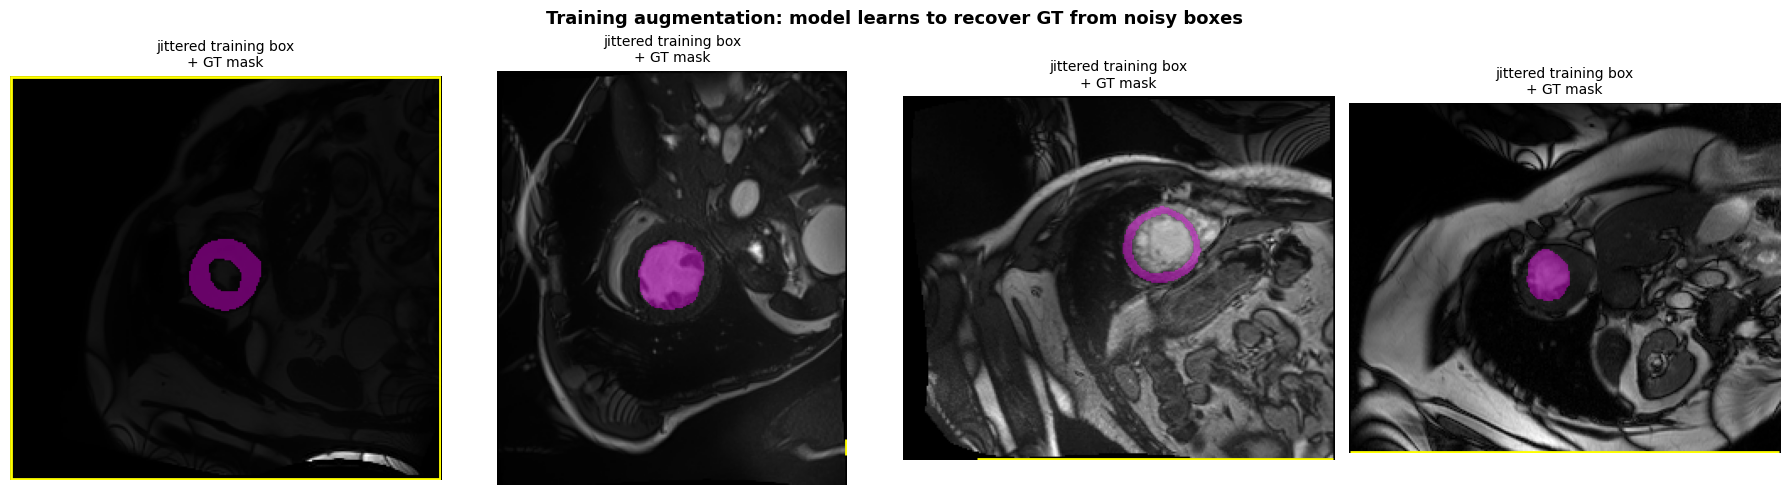

Saved: train_augmentation.png


In [34]:
# ==============================================================
# CELL 10 — Training dataset with JITTERED-BOX augmentation
# This is the mechanism that buys robustness: the model is trained
# to recover the true mask from NOISY boxes (sigma ~ TRAIN_SIGMA).
# Each sample: (image embedding inputs, jittered box, GT structure mask)
# ==============================================================
from torch.utils.data import Dataset, DataLoader

class ACDCPromptDataset(Dataset):
    """Yields (rgb, box_xyxy, gt_mask_HxW) with random box jitter."""
    def __init__(self, slices, train_sigma, seed=CFG.SEED):
        self.items = []
        for s in slices:
            for struct in CFG.LABELS:
                gt = (s["mask"] == CFG.LABELS[struct]).astype(np.uint8)
                if gt.sum() < 10:
                    continue
                self.items.append((s["img"], gt))
        self.train_sigma = train_sigma
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img, gt = self.items[idx]
        rgb = to_rgb(img); H, W = rgb.shape[:2]
        clean = box_from_mask(gt)
        frac = float(self.rng.uniform(0, self.train_sigma))   # 0..TRAIN_SIGMA
        box = make_noisy_box_prop(clean, frac,
                                  seed=int(self.rng.integers(1e9)), W=W, H=H)
        return rgb, box.astype(np.float32), gt.astype(np.float32)


def collate(batch):
    # SAM processes one image at a time for embeddings; we keep lists.
    rgbs  = [b[0] for b in batch]
    boxes = [b[1] for b in batch]
    gts   = [b[2] for b in batch]
    return rgbs, boxes, gts

set_all_seeds()
train_ds = ACDCPromptDataset(train_slices, CFG.TRAIN_SIGMA)
train_dl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                      collate_fn=collate)
print(f"Training samples (slice×structure): {len(train_ds)}")

# ---- Visualize what the augmentation feeds the model ----
set_all_seeds()
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax in axes:
    rgb, box, gt = train_ds[random.randint(0, len(train_ds)-1)]
    ax.imshow(rgb)
    ax.imshow(np.ma.masked_where(gt == 0, gt), alpha=0.4, cmap='spring')
    ax.add_patch(patches.Rectangle((box[0], box[1]),
                 box[2]-box[0], box[3]-box[1],
                 linewidth=2, edgecolor='yellow', facecolor='none'))
    ax.set_title("jittered training box\n+ GT mask", fontsize=10)
    ax.axis('off')
plt.suptitle("Training augmentation: model learns to recover GT from noisy boxes",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/train_augmentation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: train_augmentation.png")

In [ ]:
# ==============================================================
# CELL 11 — Train loop + best-checkpoint saving + loss curve
# Saves adapters every time val loss improves (best checkpoint),
# plus a periodic "latest" save so a disconnect never loses progress.
# Restores the BEST weights into `sam` at the end.
# ==============================================================
import time, copy
from mobile_sam.utils.transforms import ResizeLongestSide
transform = ResizeLongestSide(sam.image_encoder.img_size)

optimizer = torch.optim.AdamW(
    [p for p in sam.parameters() if p.requires_grad], lr=CFG.LR)
bce = nn.BCEWithLogitsLoss()

BEST_PATH   = f"{CFG.OUT_DIR}/mobilesam_lora_BEST.pt"
LATEST_PATH = f"{CFG.OUT_DIR}/mobilesam_lora_latest.pt"

def adapter_state():
    """Only the LoRA tensors — small, fast to save."""
    return {k: v.detach().cpu().clone()
            for k, v in sam.state_dict().items() if (".A" in k or ".B" in k)}

def encode_image(rgb):
    x = transform.apply_image(rgb)
    x = torch.as_tensor(x, device=DEVICE).permute(2, 0, 1).contiguous()[None]
    x = sam.preprocess(x)
    with torch.no_grad():
        emb = sam.image_encoder(x)
    return emb, x.shape[-2:]

def forward_one(rgb, box, gt):
    H, W = rgb.shape[:2]
    emb, input_size = encode_image(rgb)
    box_t = transform.apply_boxes(box[None, :], (H, W))
    box_t = torch.as_tensor(box_t, dtype=torch.float, device=DEVICE)
    sparse, dense = sam.prompt_encoder(points=None, boxes=box_t, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False)
    logits = sam.postprocess_masks(low_res, input_size, (H, W))
    gt_t = torch.as_tensor(gt, device=DEVICE)[None, None]
    return logits, gt_t

set_all_seeds()
loss_history, val_history = [], []
best_val = float("inf")
best_state = None
best_epoch = -1
t0 = time.time()

for epoch in range(CFG.EPOCHS):
    # ---- train ----
    sam.train(); running = 0.0; nb = 0
    for rgbs, boxes, gts in train_dl:
        optimizer.zero_grad()
        batch_loss = 0.0
        for rgb, box, gt in zip(rgbs, boxes, gts):
            logits, gt_t = forward_one(rgb, box, gt)
            batch_loss = batch_loss + dice_torch(logits, gt_t) + bce(logits, gt_t.float())
        batch_loss = batch_loss / len(rgbs)
        batch_loss.backward(); optimizer.step()
        running += batch_loss.item(); nb += 1
    train_loss = running / max(nb, 1)
    loss_history.append(train_loss)

    # ---- validation ----
    sam.eval(); vloss = 0.0; vn = 0
    set_all_seeds(CFG.SEED + epoch)
    with torch.no_grad():
        for s in random.sample(val_slices, min(8, len(val_slices))):
            for struct in CFG.LABELS:
                gt = (s["mask"] == CFG.LABELS[struct]).astype(np.float32)
                if gt.sum() < 10: continue
                rgb = to_rgb(s["img"]); H, W = rgb.shape[:2]
                clean = box_from_mask(gt)
                box = make_noisy_box_prop(clean, CFG.TRAIN_SIGMA,
                                          seed=epoch, W=W, H=H).astype(np.float32)
                logits, gt_t = forward_one(rgb, box, gt)
                vloss += (dice_torch(logits, gt_t) + bce(logits, gt_t.float())).item(); vn += 1
    val_loss = vloss / max(vn, 1)
    val_history.append(val_loss)

    # ---- checkpointing ----
    torch.save(adapter_state(), LATEST_PATH)        # always save latest
    improved = ""
    if val_loss < best_val:
        best_val = val_loss
        best_state = adapter_state()
        best_epoch = epoch + 1
        torch.save(best_state, BEST_PATH)           # save best
        improved = "  ← best, saved"

    elapsed = time.time() - t0
    eta = elapsed / (epoch + 1) * (CFG.EPOCHS - epoch - 1)
    print(f"epoch {epoch+1:>2}/{CFG.EPOCHS}  train {train_loss:.4f}  "
          f"val {val_loss:.4f}  | {elapsed:.0f}s, ETA {eta:.0f}s{improved}")

# ---- restore BEST weights into the live model ----
if best_state is not None:
    missing = sam.load_state_dict(best_state, strict=False)
    print(f"\nRestored BEST adapters from epoch {best_epoch} "
          f"(val {best_val:.4f}). Saved: {BEST_PATH}")
else:
    print("\nNo best state recorded (training may not have run).")

# ---- loss curve, marking the best epoch ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(loss_history)+1), loss_history, 'b-o', label='train')
ax.plot(range(1, len(val_history)+1), val_history, 'r-s', label='val')
if best_epoch > 0:
    ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5,
               label=f'best (epoch {best_epoch})')
ax.set_xlabel("epoch"); ax.set_ylabel("Dice+BCE loss")
ax.set_title("LoRA finetuning loss", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG.OUT_DIR}/loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve.png")

epoch  1/20  train 0.8308  val 0.8158  | 407s, ETA 7731s  ← best, saved
epoch  2/20  train 0.7720  val 0.8038  | 814s, ETA 7325s  ← best, saved
epoch  3/20  train 0.7582  val 0.7823  | 1222s, ETA 6927s  ← best, saved
epoch  4/20  train 0.7480  val 0.7386  | 1629s, ETA 6518s  ← best, saved
epoch  5/20  train 0.7380  val 0.7583  | 2036s, ETA 6108s
